# UAV Battery Tool — Notebook 03: Discharge Simulation

**Model:** V_terminal = V_ocv(SoC) - dV_ohmic(T) - dV_ct(T,SoC) - dV_conc(I,SoC)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings; warnings.filterwarnings("ignore")

from batteries.database import BatteryDatabase
from batteries.voltage_model import (
    CHEM_VOLTAGE_PARAMS, arrhenius_scale,
    r_ohmic_mohm, r_ct_mohm, total_pack_resistance_mohm, terminal_voltage,
)
from mission.simulator import run_simulation, compare_batteries, temperature_sweep

plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True, "grid.alpha": 0.25})
DB_PATH = "../battery_db.xlsx"
db = BatteryDatabase(DB_PATH).load()
print(db.summary())

═══ Battery Database Summary ═══
  Chemistries       : 9
  Cells             : 11
  Battery packs     : 8
  Discharge points  : 132
  Equipment items   : 29
  UAV configurations: 3
  Mission profiles  : 3


## 1 · Chemistry Resistance vs Temperature

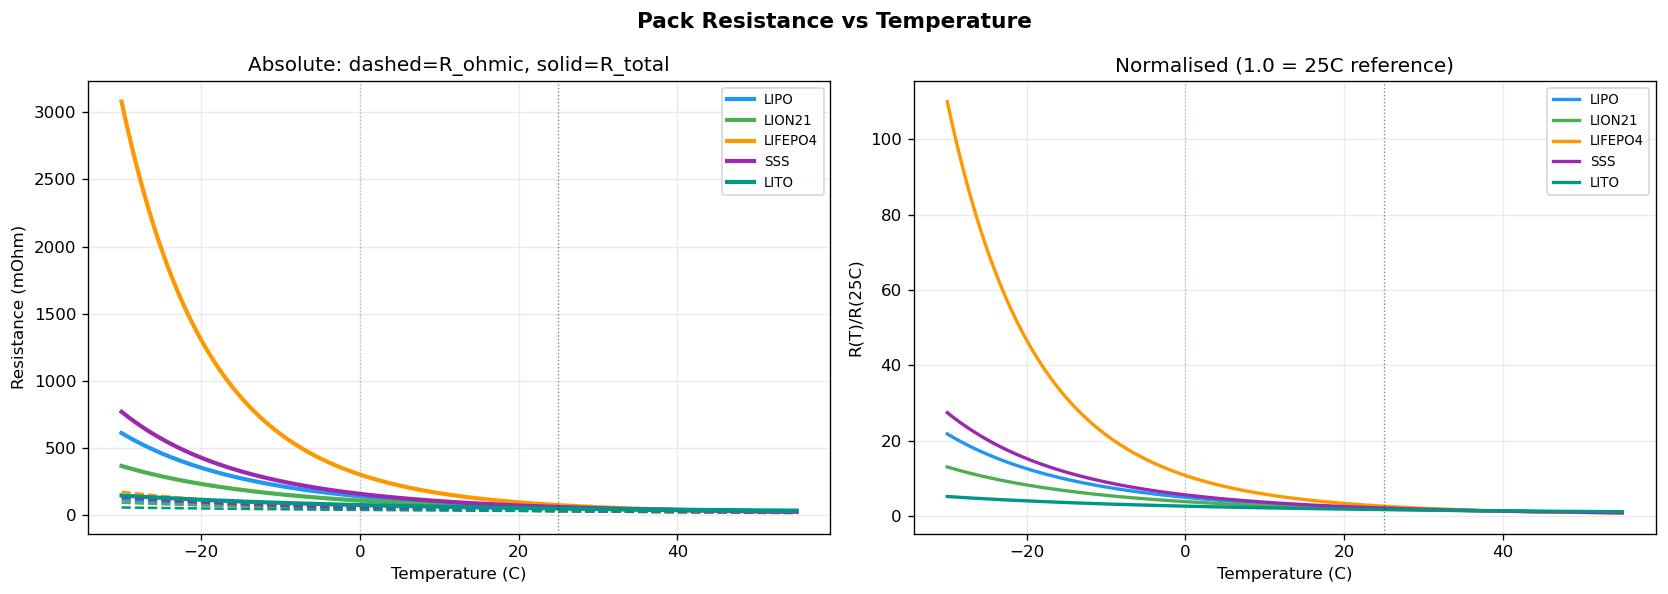


Resistance multiplier vs temperature (relative to 25C):


Temp (C),-20,-10,0,25,45
Chemistry,,,,,
LIFEPO4,46.67,21.52,10.75,2.6,1.10
LION21,8.24,5.48,3.81,1.8,1.12
LIPO,12.56,7.68,4.95,2.0,1.13
LITO,4.02,3.20,2.61,1.7,1.29
SSS,15.24,8.99,5.60,2.1,1.13


In [2]:
temps = np.linspace(-30, 55, 200)
chemistries = ["LIPO", "LION21", "LIFEPO4", "SSS", "LITO"]
R_REF = 28.0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pack Resistance vs Temperature", fontsize=13, fontweight="bold")
colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#009688"]
for chem, color in zip(chemistries, colors):
    r_ohm = [r_ohmic_mohm(R_REF, chem, t) for t in temps]
    r_ct  = [r_ct_mohm(R_REF, chem, t, 80) for t in temps]
    r_tot = [ro+rc for ro,rc in zip(r_ohm,r_ct)]
    axes[0].plot(temps, r_ohm, color=color, linewidth=1.5, linestyle="--")
    axes[0].plot(temps, r_tot, color=color, linewidth=2.5, label=chem)
    axes[1].plot(temps, [r/R_REF for r in r_tot], color=color, linewidth=2, label=chem)
for ax in axes:
    ax.axvline(25,  color="black",    linewidth=0.8, linestyle=":", alpha=0.5)
    ax.axvline(0,   color="steelblue", linewidth=0.8, linestyle=":", alpha=0.4)
    ax.axvline(-25, color="red",       linewidth=0.8, linestyle=":", alpha=0.4)
axes[0].set_xlabel("Temperature (°C)"); axes[0].set_ylabel("Resistance (mΩ)")
axes[0].set_title("Absolute: dashed=R_ohmic, solid=R_total"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("Temperature (°C)"); axes[1].set_ylabel("R(T)/R(25°C)")
axes[1].set_title("Normalised (1.0 = 25°C reference)    ◄ red line = −25°C")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("resistance_vs_temperature.png", bbox_inches="tight"); plt.show()

rows = []
for chem in chemistries:
    for t in [-25,-15,-5,0,15,25,40]:
        r = total_pack_resistance_mohm(R_REF, chem, t, 80)
        rows.append({"Chemistry":chem,"Temp (°C)":t,"Multiplier":round(r/R_REF,2)})
tbl = pd.DataFrame(rows).pivot_table(index="Chemistry", columns="Temp (°C)", values="Multiplier")
print("
Resistance multiplier vs temperature (relative to 25°C):")
print(tbl.to_string())
print("
Note: multipliers >1 are physical — cold electrolyte raises both ohmic and")
print("      charge-transfer resistance via Arrhenius kinetics.")
print("      High values (e.g. 10x at -25°C for LIFEPO4) mean the pack will trigger")
print("      its voltage-cutoff BMS protection before SoC reaches zero.")

## 2 · Voltage Sag Anatomy

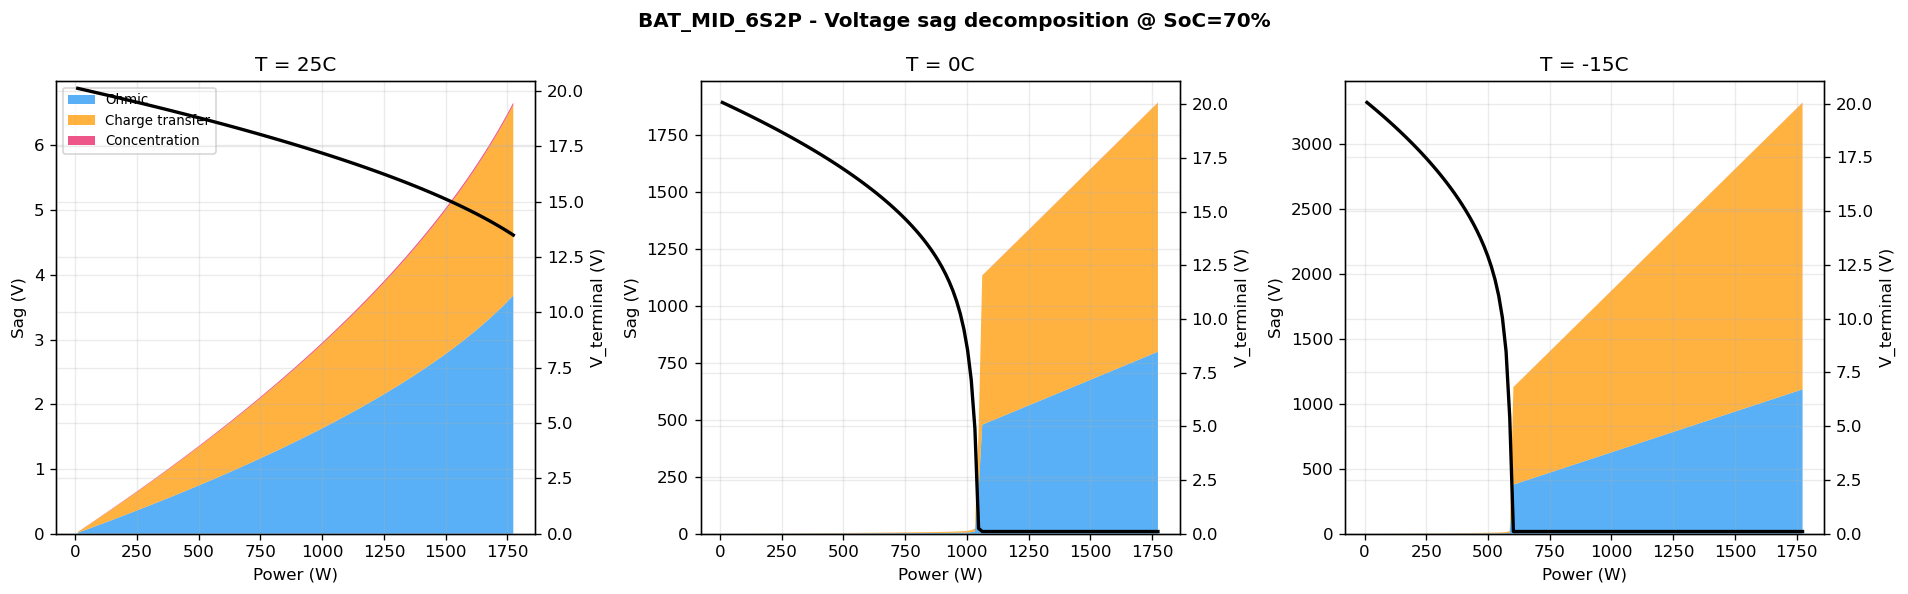

In [3]:
PACK_ID = "BAT_MID_6S2P"
pack = db.packs[PACK_ID]
POWERS = np.linspace(10, pack.max_cont_discharge_w * 0.9, 120)
TEMPS_SAG = [25, 0, -15]; SOC_FIXED = 70.0
V_OCV = pack.pack_voltage_nom * 0.92
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f"{PACK_ID} - Voltage sag decomposition @ SoC={SOC_FIXED:.0f}%", fontsize=12, fontweight="bold")
for ax, temp in zip(axes, TEMPS_SAG):
    v_terms, dv_ohm, dv_ct, dv_conc = [], [], [], []
    for pw in POWERS:
        v, i, bk = terminal_voltage(power_w=pw, soc_pct=SOC_FIXED, temp_c=temp,
            v_ocv_pack=V_OCV, r_pack_mohm=pack.internal_resistance_mohm,
            chem_id=pack.chemistry_id, capacity_ah=pack.pack_capacity_ah,
            cells_series=pack.cells_series, cells_parallel=pack.cells_parallel)
        v_terms.append(v); dv_ohm.append(bk["dv_ohmic"])
        dv_ct.append(bk["dv_ct"]); dv_conc.append(bk["dv_conc"])
    ax.stackplot(POWERS, dv_ohm, dv_ct, dv_conc,
        labels=["Ohmic","Charge transfer","Concentration"],
        colors=["#2196F3","#FF9800","#E91E63"], alpha=0.75)
    ax2 = ax.twinx()
    ax2.plot(POWERS, v_terms, "k-", linewidth=2, label="V_terminal")
    ax2.set_ylabel("V_terminal (V)"); ax2.set_ylim(bottom=0)
    ax.set_xlabel("Power (W)"); ax.set_ylabel("Sag (V)"); ax.set_title(f"T = {temp}C")
    if ax == axes[0]: ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig("voltage_sag_anatomy.png", bbox_inches="tight"); plt.show()

## 3 · Single Mission Simulation

In [4]:
# ── Load settings from 00_configurator.ipynb (analysis_config.json) ───────────
import json as _json, os as _os
_CFG_PATH = _os.path.join(_os.path.dirname(_os.path.abspath('.')), 'analysis_config.json')
if not _os.path.exists(_CFG_PATH):
    _CFG_PATH = 'analysis_config.json'
_cfg = {}
if _os.path.exists(_CFG_PATH):
    with open(_CFG_PATH) as _f:
        _cfg = _json.load(_f)
    print(f'Loaded config from {_CFG_PATH}')
else:
    print('No analysis_config.json found — using defaults below (run 00_configurator first)')

# ── Values from configurator (overridden by manual entries below if desired) ───
SIM_PACK_ID    = _cfg.get('selected_batteries', ['BAT_MID_6S2P'])[0] if isinstance(_cfg.get('selected_batteries'), list) else 'BAT_MID_6S2P'
SIM_MISSION_ID = _cfg.get('mission_id',     'SURVEY_STD')
SIM_UAV_ID     = _cfg.get('uav_id',         'HEX_SURVEY_900')
AMBIENT_TEMP_C = _cfg.get('ambient_temp_c', 25.0)
TEMP_SWEEP     = _cfg.get('temp_sweep',     [-25, -10, 0, 15, 25, 40])
COMPARE_PACK_IDS = (_cfg.get('selected_batteries', ['BAT_MID_6S2P', 'BAT_MID_6S4P', 'BAT_AG_6S1P'])
                    if isinstance(_cfg.get('selected_batteries'), list)
                    else ['BAT_MID_6S2P', 'BAT_MID_6S4P', 'BAT_AG_6S1P'])


# ── Reconstruct combined pack if configured ────────────────────────────────────
_combo_cfg = _cfg.get('battery_combination')
if _combo_cfg:
    from batteries.builder import combine_packs as _combine_packs
    _combo_packs = [db.packs[bid] for bid in _combo_cfg.get('packs', []) if bid in db.packs]
    if len(_combo_packs) >= 2:
        _combined = _combine_packs(_combo_packs, topology=_combo_cfg.get('topology', 'series'))
        db.packs[_combined.battery_id] = _combined
        print(f'Combined pack registered: {_combined.battery_id}  '
              f'({_combined.pack_voltage_nom:.1f}V {_combined.pack_energy_wh:.0f}Wh)')

# ── Manual overrides (uncomment to override configurator values) ────────────
# SIM_PACK_ID = "BAT_MID_6S2P"
# SIM_MISSION_ID = "SURVEY_STD"
# SIM_UAV_ID = "HEX_SURVEY_900"
# AMBIENT_TEMP_C = 25.0
pack    = db.packs[SIM_PACK_ID]
mission = db.missions[SIM_MISSION_ID]
uav     = db.uav_configs[SIM_UAV_ID]
result  = run_simulation(pack=pack, mission=mission, uav=uav,
    discharge_pts=db.discharge_pts, initial_soc_pct=100.0,
    ambient_temp_c=AMBIENT_TEMP_C, peukert_k=1.05, dt_s=1.0)
print(result.summary())

════════════════════════════════════════════════════
 Simulation: BAT_MID_6S2P × SURVEY_STD  [COMPLETED]
════════════════════════════════════════════════════
  Duration         : 1469 s  (24.5 min)
  Energy consumed  : 127.91 Wh
  Initial SoC      : 100.0 %
  Final SoC        : 34.0 %
  Min voltage      : 19.657 V
  Max current      : 30.7 A
  Peak sag total   : 1.537 V
  Peak temperature : 30.7 °C


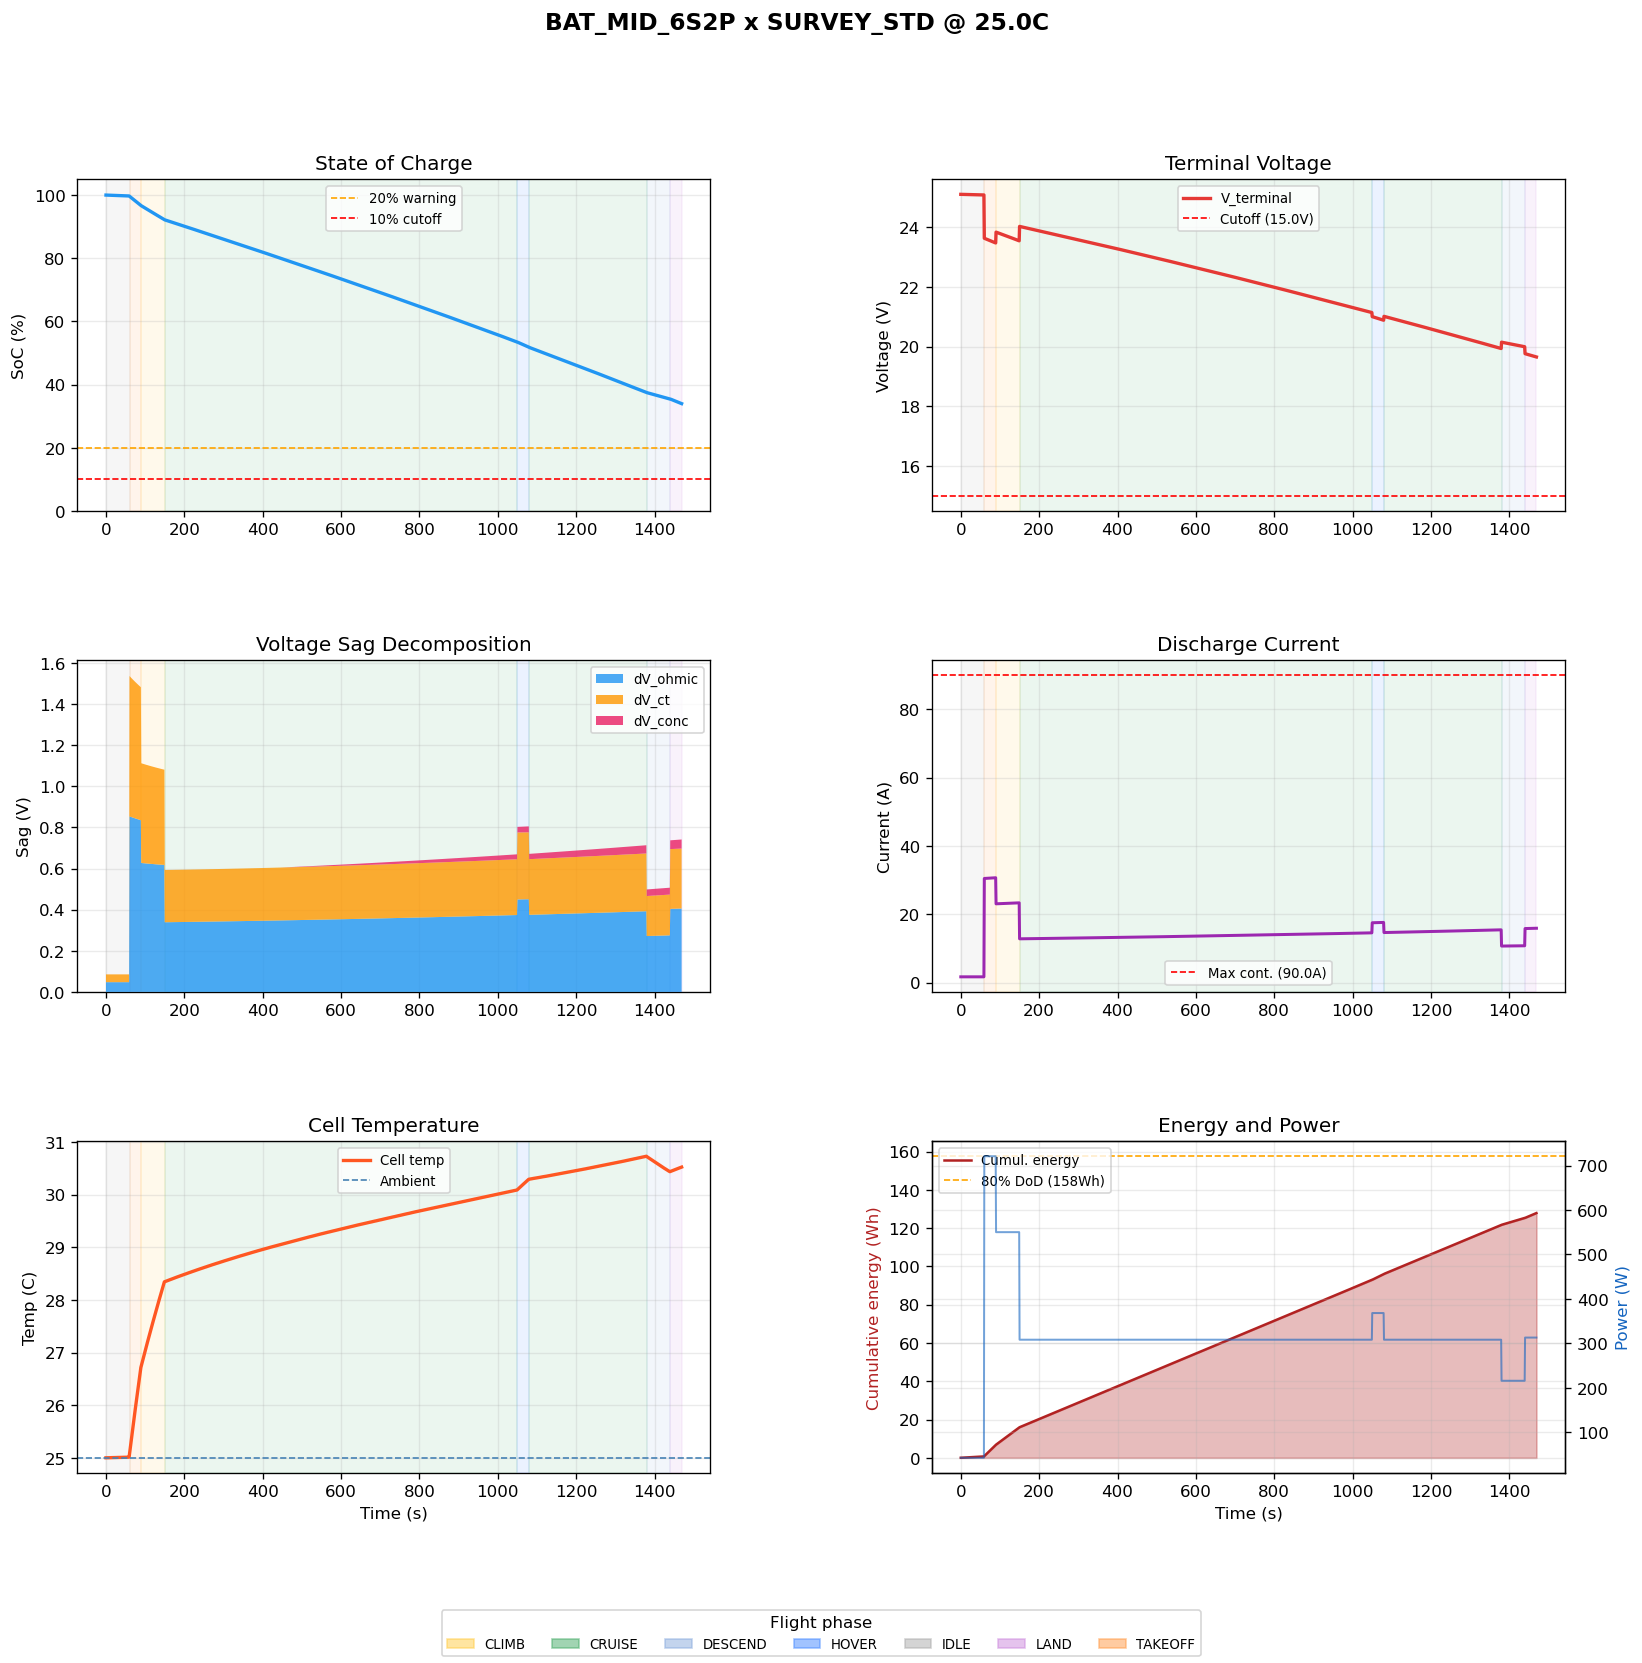

In [5]:
PHASE_COLORS = {
    "IDLE":            "#AAAAAA",  # ground idle
    "TAKEOFF":         "#FF9944",  # full power lift-off
    "CLIMB":           "#FFCC44",  # powered climb
    "CRUISE":          "#44AA66",  # level cruise
    "HOVER":           "#4488FF",  # stationary hover
    "DESCEND":         "#88AADD",  # descent
    "LAND":            "#CC88DD",  # landing
    "PAYLOAD_OPS":     "#FF6688",  # payload operations
    "EMERGENCY":       "#FF2222",  # emergency
    # ── Fixed-wing VTOL phases ────────────────────────────────────────────
    "VTOL_TRANSITION": "#FF6611",  # lift+thrust overlap during transition
    "VTOL_HOVER":      "#22AAFF",  # explicit multirotor hover
    "FW_CRUISE":       "#00CC77",  # efficient fixed-wing cruise
    "FW_CLIMB":        "#AACC44",  # fixed-wing climb
    "FW_DESCEND":      "#99CCEE",  # glide descent
}
def shade_phases(ax, res):
    prev, t0 = res.phase_type[0], res.time_s[0]
    for t, ph in zip(res.time_s[1:], res.phase_type[1:]):
        if ph != prev:
PHASE_COLORS = {
    "IDLE":            "#AAAAAA",  # ground idle
    "TAKEOFF":         "#FF9944",  # full power lift-off
    "CLIMB":           "#FFCC44",  # powered climb
    "CRUISE":          "#44AA66",  # level cruise
    "HOVER":           "#4488FF",  # stationary hover
    "DESCEND":         "#88AADD",  # descent
    "LAND":            "#CC88DD",  # landing
    "PAYLOAD_OPS":     "#FF6688",  # payload operations
    "EMERGENCY":       "#FF2222",  # emergency
    # ── Fixed-wing VTOL phases ────────────────────────────────────────────
    "VTOL_TRANSITION": "#FF6611",  # lift+thrust overlap during transition
    "VTOL_HOVER":      "#22AAFF",  # explicit multirotor hover
    "FW_CRUISE":       "#00CC77",  # efficient fixed-wing cruise
    "FW_CLIMB":        "#AACC44",  # fixed-wing climb
    "FW_DESCEND":      "#99CCEE",  # glide descent
}
            t0 = t
        prev = ph
PHASE_COLORS = {
    "IDLE":            "#AAAAAA",  # ground idle
    "TAKEOFF":         "#FF9944",  # full power lift-off
    "CLIMB":           "#FFCC44",  # powered climb
    "CRUISE":          "#44AA66",  # level cruise
    "HOVER":           "#4488FF",  # stationary hover
    "DESCEND":         "#88AADD",  # descent
    "LAND":            "#CC88DD",  # landing
    "PAYLOAD_OPS":     "#FF6688",  # payload operations
    "EMERGENCY":       "#FF2222",  # emergency
    # ── Fixed-wing VTOL phases ────────────────────────────────────────────
    "VTOL_TRANSITION": "#FF6611",  # lift+thrust overlap during transition
    "VTOL_HOVER":      "#22AAFF",  # explicit multirotor hover
    "FW_CRUISE":       "#00CC77",  # efficient fixed-wing cruise
    "FW_CLIMB":        "#AACC44",  # fixed-wing climb
    "FW_DESCEND":      "#99CCEE",  # glide descent
}
t = np.array(result.time_s)
fig = plt.figure(figsize=(16,14))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(f"{SIM_PACK_ID} x {SIM_MISSION_ID} @ {AMBIENT_TEMP_C}C", fontsize=14, fontweight="bold")
ax1 = fig.add_subplot(gs[0,0])
ax1.plot(t, result.soc_pct, "#2196F3", linewidth=2)
ax1.axhline(20, color="orange", linestyle="--", linewidth=1, label="20% warning")
ax1.axhline(10, color="red",    linestyle="--", linewidth=1, label="10% cutoff")
shade_phases(ax1, result); ax1.set_ylabel("SoC (%)"); ax1.set_title("State of Charge")
ax1.legend(fontsize=8); ax1.set_ylim(0,105)
ax2 = fig.add_subplot(gs[0,1])
ax2.plot(t, result.voltage_v, "#E53935", linewidth=2, label="V_terminal")
ax2.axhline(pack.pack_voltage_cutoff, color="red", linestyle="--", linewidth=1,
            label=f"Cutoff ({pack.pack_voltage_cutoff}V)")
shade_phases(ax2, result); ax2.set_ylabel("Voltage (V)"); ax2.set_title("Terminal Voltage")
ax2.legend(fontsize=8)
ax3 = fig.add_subplot(gs[1,0])
ax3.stackplot(t, result.dv_ohmic, result.dv_ct, result.dv_conc,
    labels=["dV_ohmic","dV_ct","dV_conc"],
    colors=["#2196F3","#FF9800","#E91E63"], alpha=0.80, zorder=3)
shade_phases(ax3, result); ax3.set_ylabel("Sag (V)"); ax3.set_title("Voltage Sag Decomposition")
ax3.legend(fontsize=8, loc="upper right")
ax4 = fig.add_subplot(gs[1,1])
ax4.plot(t, result.current_a, "#9C27B0", linewidth=1.8)
ax4.axhline(pack.max_cont_discharge_a, color="red", linestyle="--", linewidth=1,
            label=f"Max cont. ({pack.max_cont_discharge_a}A)")
shade_phases(ax4, result); ax4.set_ylabel("Current (A)"); ax4.set_title("Discharge Current")
ax4.legend(fontsize=8)
ax5 = fig.add_subplot(gs[2,0])
ax5.plot(t, result.temp_c, "#FF5722", linewidth=2, label="Cell temp")
ax5.axhline(AMBIENT_TEMP_C, color="steelblue", linestyle="--", linewidth=1, label="Ambient")
shade_phases(ax5, result); ax5.set_xlabel("Time (s)"); ax5.set_ylabel("Temp (C)")
ax5.set_title("Cell Temperature"); ax5.legend(fontsize=8)
ax6  = fig.add_subplot(gs[2,1]); ax6b = ax6.twinx()
ax6.fill_between(t, result.energy_wh, alpha=0.3, color="firebrick")
ax6.plot(t, result.energy_wh, "firebrick", linewidth=1.5, label="Cumul. energy")
ax6b.plot(t, result.power_w, "#1565C0", linewidth=1.2, alpha=0.6)
ax6.axhline(pack.pack_energy_wh * 0.80, color="orange", linestyle="--", linewidth=1,
            label=f"80% DoD ({pack.pack_energy_wh*0.8:.0f}Wh)")
ax6.set_xlabel("Time (s)"); ax6.set_ylabel("Cumulative energy (Wh)", color="firebrick")
ax6b.set_ylabel("Power (W)", color="#1565C0"); ax6.set_title("Energy and Power")
ax6.legend(fontsize=8, loc="upper left")
PHASE_COLORS = {
    "IDLE":            "#AAAAAA",  # ground idle
    "TAKEOFF":         "#FF9944",  # full power lift-off
    "CLIMB":           "#FFCC44",  # powered climb
    "CRUISE":          "#44AA66",  # level cruise
    "HOVER":           "#4488FF",  # stationary hover
    "DESCEND":         "#88AADD",  # descent
    "LAND":            "#CC88DD",  # landing
    "PAYLOAD_OPS":     "#FF6688",  # payload operations
    "EMERGENCY":       "#FF2222",  # emergency
    # ── Fixed-wing VTOL phases ────────────────────────────────────────────
    "VTOL_TRANSITION": "#FF6611",  # lift+thrust overlap during transition
    "VTOL_HOVER":      "#22AAFF",  # explicit multirotor hover
    "FW_CRUISE":       "#00CC77",  # efficient fixed-wing cruise
    "FW_CLIMB":        "#AACC44",  # fixed-wing climb
    "FW_DESCEND":      "#99CCEE",  # glide descent
}
           for p in sorted(set(result.phase_type))]
fig.legend(handles=patches, loc="lower center", ncol=8, fontsize=8, title="Flight phase")
plt.savefig("simulation_dashboard.png", bbox_inches="tight"); plt.show()

## 4 · Temperature Sensitivity Analysis

In [6]:
TEMPS_SWEEP = [-25,-20,-15,-10,-5,0,5,10,15,20,25,30,35,40,45]
sweep_results = temperature_sweep(pack=pack, mission=mission, uav=uav,
    discharge_pts=db.discharge_pts, temperatures_c=TEMPS_SWEEP, dt_s=5.0)
df_sweep = pd.DataFrame([{
    "Ambient (C)": t, "Final SoC (%)": round(r.final_soc,1),
    "Duration (s)": round(r.total_duration_s,0),
    "Energy used (Wh)": round(r.total_energy_consumed_wh,1),
    "Min V (V)": round(r.min_voltage,3), "Peak sag (V)": round(r.peak_sag_v,3),
    "Max I (A)": round(r.max_current,1), "Max T (°C)": round(r.max_temp_c,1),
    "Depleted": r.depleted, "Cutoff": r.cutoff_reason or "none"}
    for t, r in zip(TEMPS_SWEEP, sweep_results)])
print(df_sweep.to_string(index=False))
print("
Note: Voltage cutoff = pack BMS triggers before SoC depletes (common in cold temps)")

 Ambient (C)  Final SoC (%)  Energy used (Wh)  Min V (V)  Peak sag (V)  Max I (A)  Max T (C)  Depleted
         -25           10.0               1.7      0.100      2071.854     7210.0   132165.6      True
         -20           10.0             123.8     11.428        14.529       63.1        0.4      True
         -15           11.4             127.9     16.401         7.722       41.3        2.3     False
         -10           16.2             127.9     17.325         5.672       37.0        4.9     False
          -5           20.4             127.9     17.903         4.422       34.8        7.9     False
           0           24.3             127.9     18.367         3.559       33.4       11.1     False
           5           27.2             127.9     18.740         2.926       32.4       14.7     False
          10           29.7             127.9     19.056         2.446       31.8       18.4     False
          15           31.9             127.9     19.332         2.072   

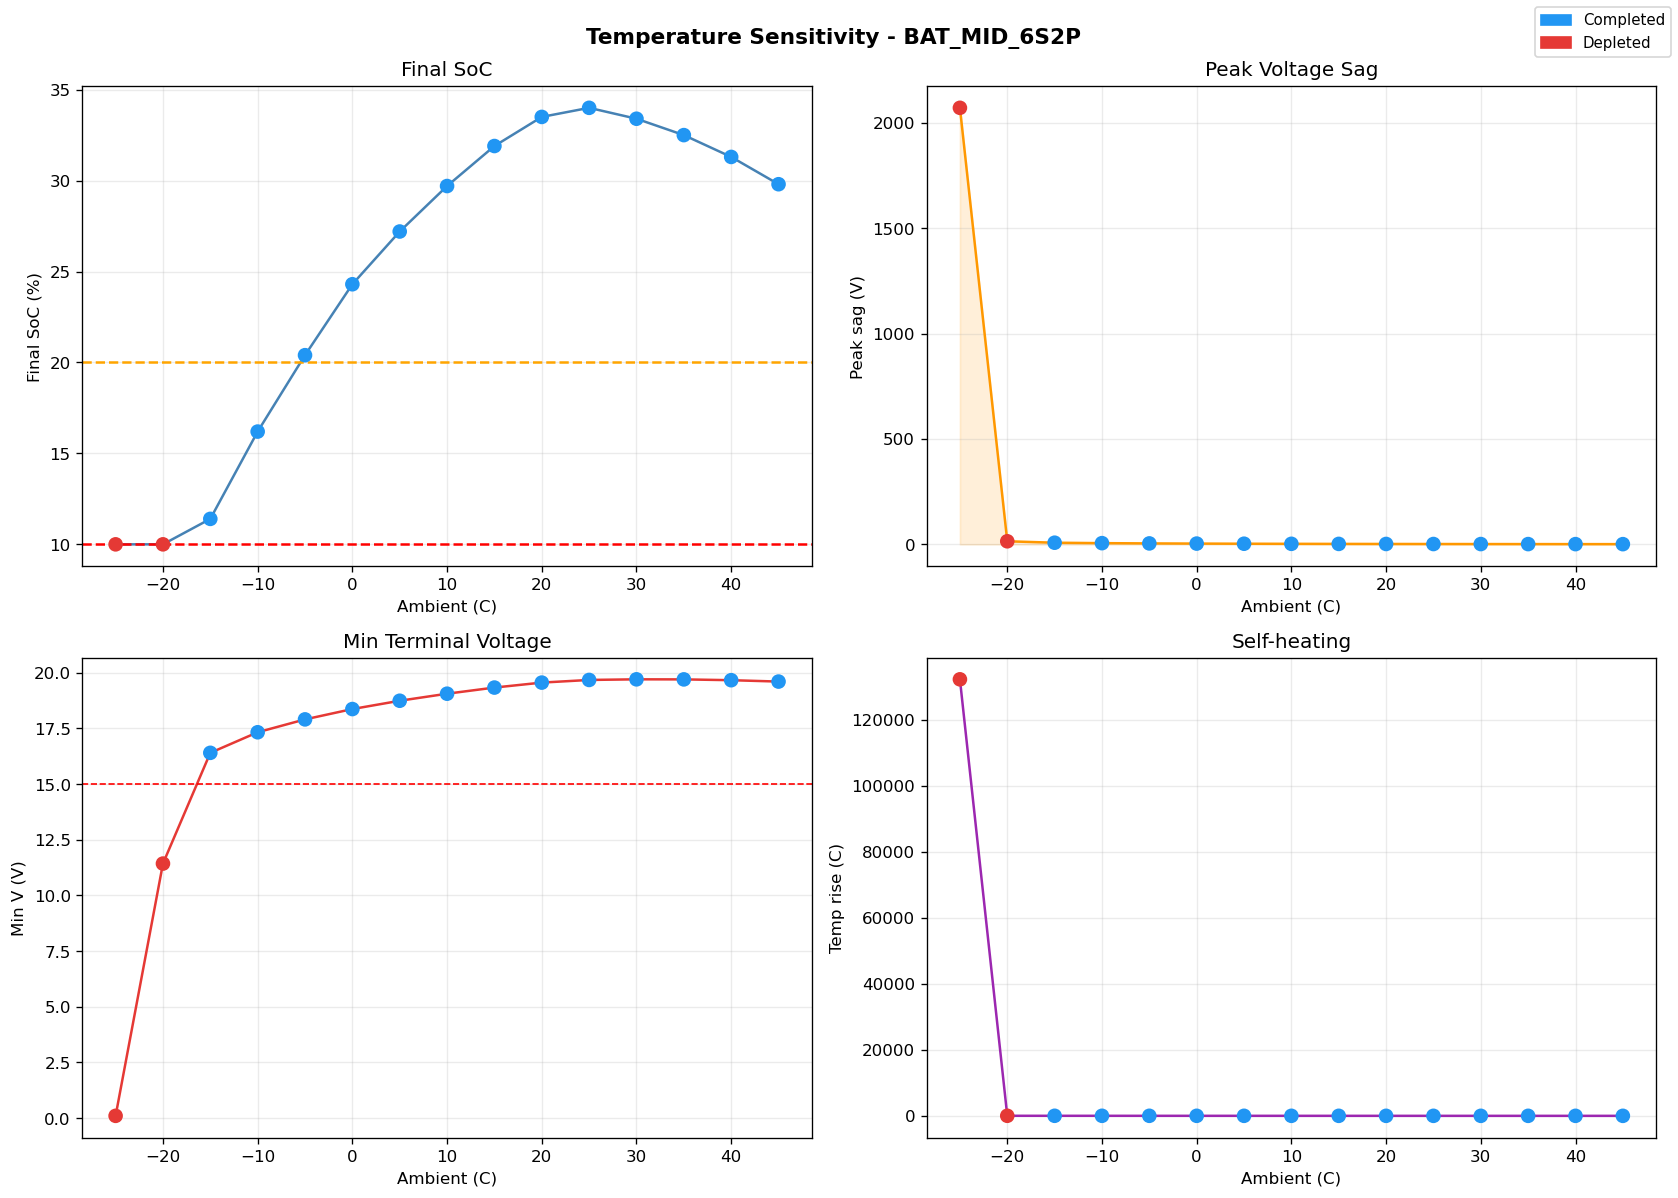

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Temperature Sensitivity - {SIM_PACK_ID}", fontsize=13, fontweight="bold")
t_vals = df_sweep["Ambient (C)"].values
colors_pt = ["#E53935" if d else "#2196F3" for d in df_sweep["Depleted"]]
axes[0,0].scatter(t_vals, df_sweep["Final SoC (%)"], c=colors_pt, s=60, zorder=4)
axes[0,0].plot(t_vals, df_sweep["Final SoC (%)"], "steelblue", linewidth=1.5)
axes[0,0].axhline(20, color="orange", linestyle="--"); axes[0,0].axhline(10, color="red", linestyle="--")
axes[0,0].set_xlabel("Ambient (C)"); axes[0,0].set_ylabel("Final SoC (%)"); axes[0,0].set_title("Final SoC")
axes[0,1].scatter(t_vals, df_sweep["Peak sag (V)"], c=colors_pt, s=60, zorder=4)
axes[0,1].plot(t_vals, df_sweep["Peak sag (V)"], "#FF9800", linewidth=1.5)
axes[0,1].fill_between(t_vals, 0, df_sweep["Peak sag (V)"], alpha=0.15, color="#FF9800")
axes[0,1].set_xlabel("Ambient (C)"); axes[0,1].set_ylabel("Peak sag (V)"); axes[0,1].set_title("Peak Voltage Sag")
axes[1,0].scatter(t_vals, df_sweep["Min V (V)"], c=colors_pt, s=60, zorder=4)
axes[1,0].plot(t_vals, df_sweep["Min V (V)"], "#E53935", linewidth=1.5)
axes[1,0].axhline(pack.pack_voltage_cutoff, color="red", linestyle="--", linewidth=1)
axes[1,0].set_xlabel("Ambient (C)"); axes[1,0].set_ylabel("Min V (V)"); axes[1,0].set_title("Min Terminal Voltage")
temp_rise = df_sweep["Max T (C)"] - df_sweep["Ambient (C)"]
axes[1,1].scatter(t_vals, temp_rise, c=colors_pt, s=60, zorder=4)
axes[1,1].plot(t_vals, temp_rise, "#9C27B0", linewidth=1.5)
axes[1,1].set_xlabel("Ambient (C)"); axes[1,1].set_ylabel("Temp rise (C)"); axes[1,1].set_title("Self-heating")
legend_patches = [mpatches.Patch(color="#2196F3",label="Completed"),
                   mpatches.Patch(color="#E53935",label="Depleted")]
fig.legend(handles=legend_patches, loc="upper right", fontsize=9)
plt.tight_layout(); plt.savefig("temperature_sensitivity.png", bbox_inches="tight"); plt.show()

## 5 · Multi-Battery Comparison

════════════════════════════════════════════════════
 Simulation: BAT_MID_6S2P × SURVEY_STD  [COMPLETED]
════════════════════════════════════════════════════
  Duration         : 1468 s  (24.5 min)
  Energy consumed  : 127.91 Wh
  Initial SoC      : 100.0 %
  Final SoC        : 31.8 %
  Min voltage      : 19.319 V
  Max current      : 31.3 A
  Peak sag total   : 2.072 V
  Peak temperature : 22.4 °C

════════════════════════════════════════════════════
 Simulation: BAT_MID_6S4P × SURVEY_STD  [COMPLETED]
════════════════════════════════════════════════════
  Duration         : 1468 s  (24.5 min)
  Energy consumed  : 127.91 Wh
  Initial SoC      : 100.0 %
  Final SoC        : 70.3 %
  Min voltage      : 15.536 V
  Max current      : 46.4 A
  Peak sag total   : 9.683 V
  Peak temperature : 25.4 °C

════════════════════════════════════════════════════
 Simulation: BAT_AG_6S1P × SURVEY_STD  [COMPLETED]
════════════════════════════════════════════════════
  Duration         : 1468 s  (24.5 mi

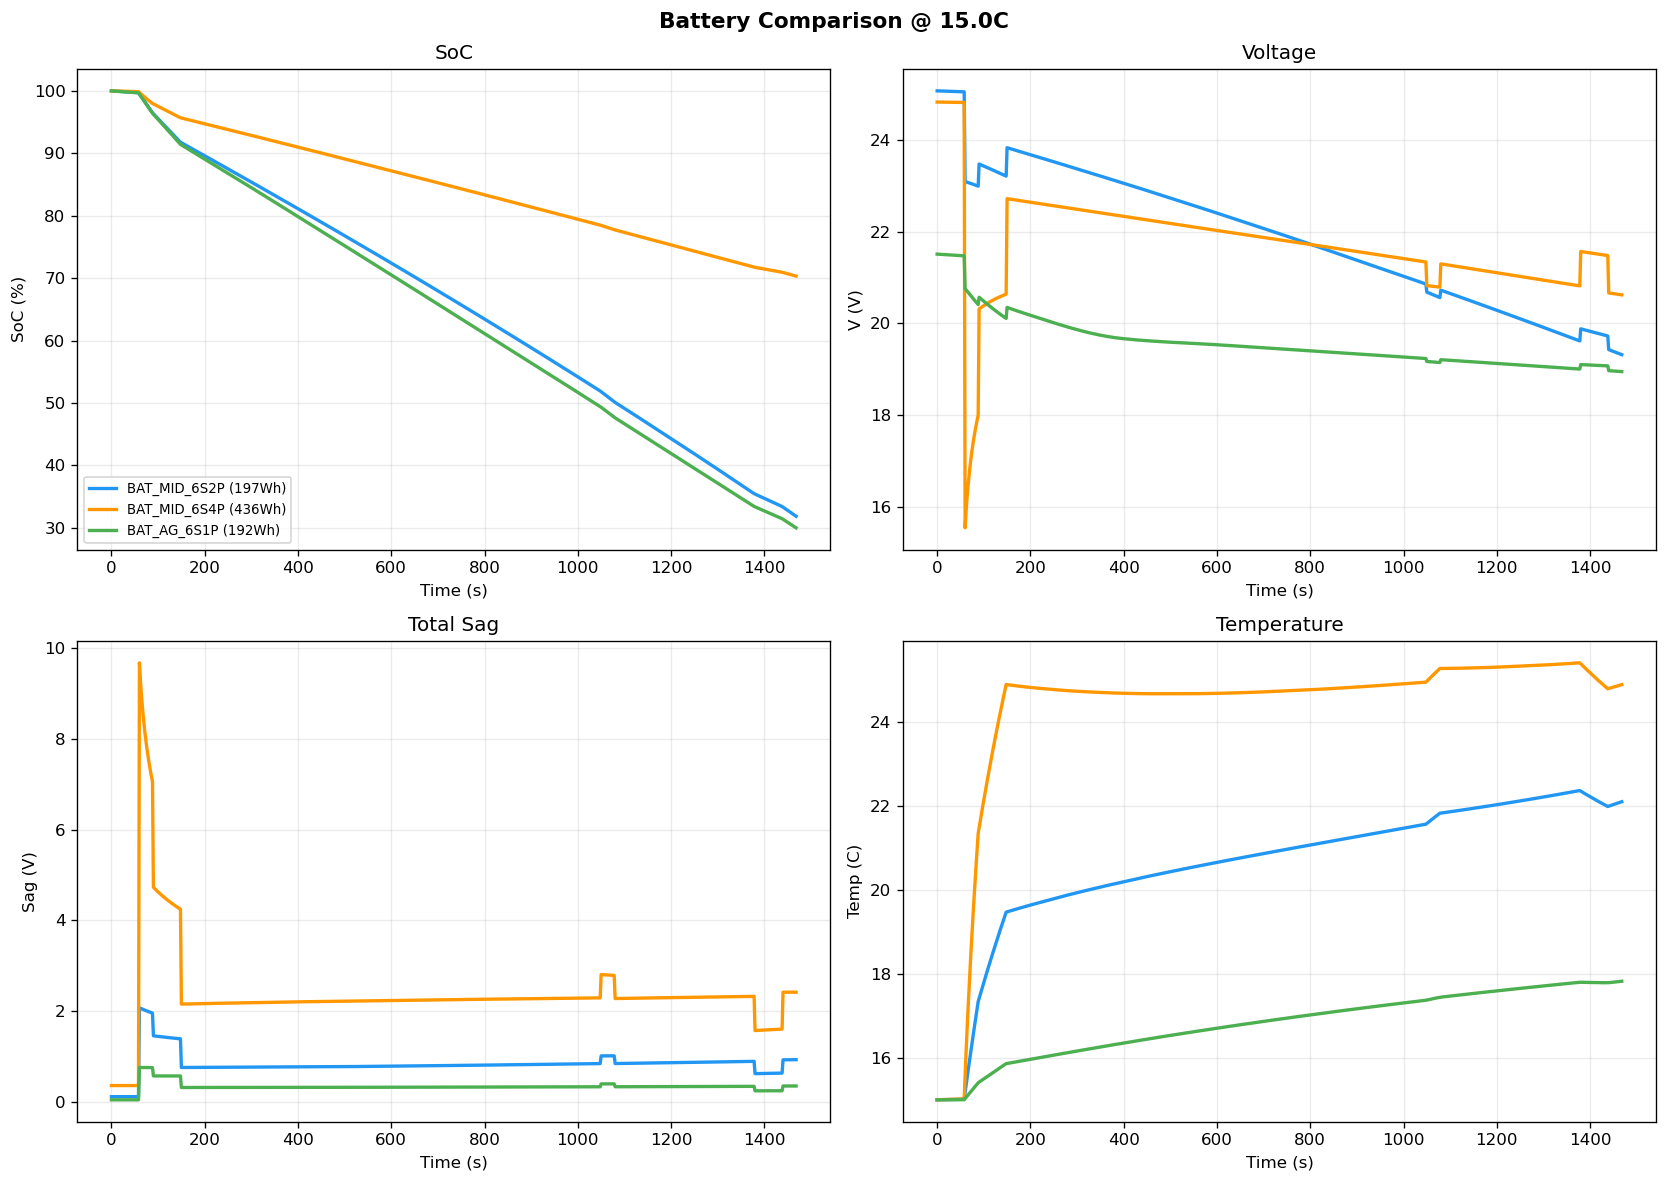

In [8]:
COMPARE_PACK_IDS = ["BAT_MID_6S2P", "BAT_MID_6S4P", "BAT_AG_6S1P"]
COMPARE_TEMP = 15.0
compare_packs = [db.packs[pid] for pid in COMPARE_PACK_IDS if pid in db.packs]
compare_results = compare_batteries(packs=compare_packs, mission=mission, uav=uav,
    discharge_pts=db.discharge_pts, ambient_temp_c=COMPARE_TEMP, dt_s=2.0)
for r in compare_results:
    print(r.summary()); print()
palette = ["#2196F3","#FF9800","#4CAF50"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Battery Comparison @ {COMPARE_TEMP}C", fontsize=13, fontweight="bold")
for r, p, col in zip(compare_results, compare_packs, palette):
    label = f"{r.pack_id} ({p.pack_energy_wh:.0f}Wh)"
    t_arr = np.array(r.time_s)
    axes[0,0].plot(t_arr, r.soc_pct, color=col, linewidth=2, label=label)
    axes[0,1].plot(t_arr, r.voltage_v, color=col, linewidth=2)
    axes[1,0].plot(t_arr, np.array(r.dv_ohmic)+np.array(r.dv_ct)+np.array(r.dv_conc), color=col, linewidth=2)
    axes[1,1].plot(t_arr, r.temp_c, color=col, linewidth=2)
for ax, (title,ylabel) in zip(axes.flat,[("SoC","SoC (%)"),("Voltage","V (V)"),("Total Sag","Sag (V)"),("Temperature","Temp (C)")]):
    ax.set_title(title); ax.set_ylabel(ylabel); ax.set_xlabel("Time (s)")
axes[0,0].legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.savefig("multi_battery_compare.png", bbox_inches="tight"); plt.show()

## 6 · Chemistry Cold-Weather Sag Comparison

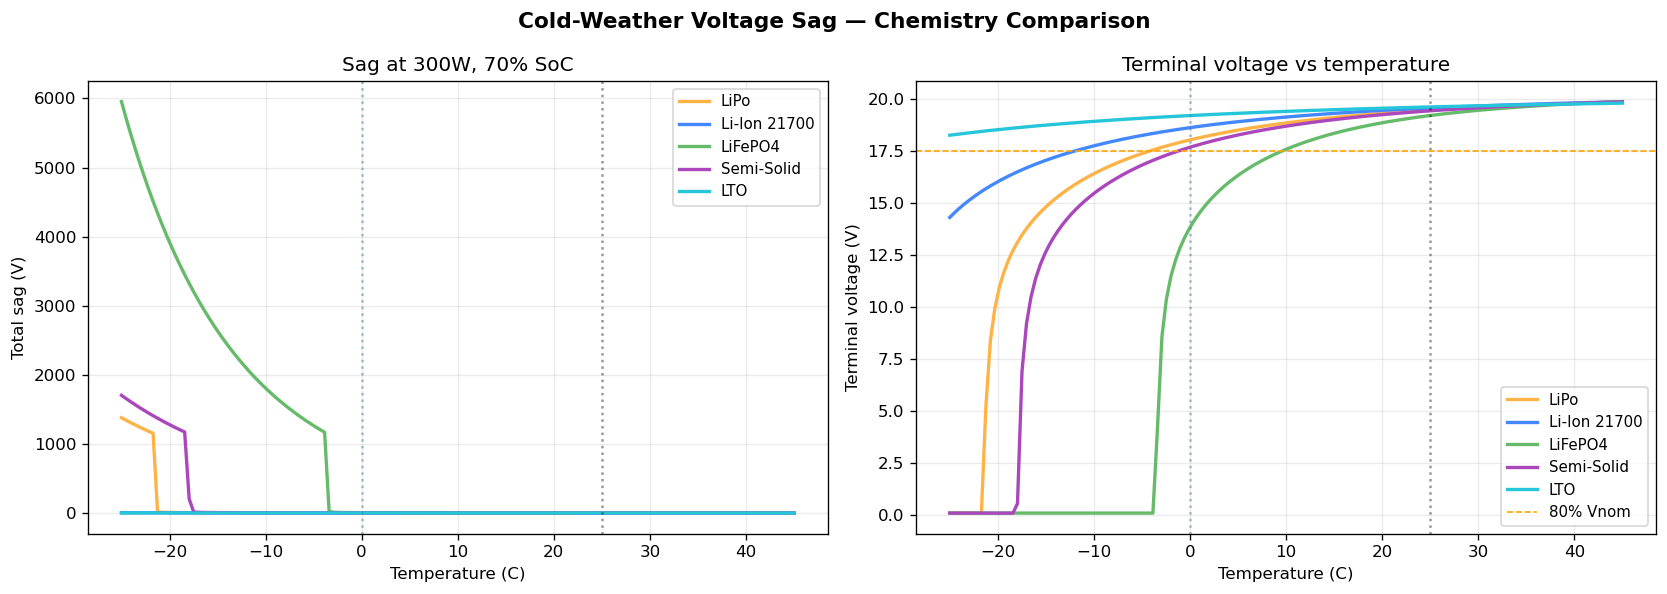

In [9]:
TEMPS_CHEM = np.linspace(-25, 45, 150)
TEST_POWER=300; TEST_SOC=70; TEST_IR=28.0; TEST_V_OCV=21.9*0.93; TEST_CAP=9.0; TEST_S,TEST_P=6,2
chemistries_cmp=["LIPO","LION21","LIFEPO4","SSS","LITO"]
chem_labels={"LIPO":"LiPo","LION21":"Li-Ion 21700","LIFEPO4":"LiFePO4","SSS":"Semi-Solid","LITO":"LTO"}
chem_clr={"LIPO":"#FFB347","LION21":"#4488FF","LIFEPO4":"#66BB6A","SSS":"#AB47BC","LITO":"#26C6DA"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cold-Weather Voltage Sag — Chemistry Comparison", fontsize=13, fontweight="bold")
for chem in chemistries_cmp:
    v_terms, total_sags = [], []
    for temp in TEMPS_CHEM:
        v, i, bk = terminal_voltage(power_w=TEST_POWER, soc_pct=TEST_SOC, temp_c=temp,
            v_ocv_pack=TEST_V_OCV, r_pack_mohm=TEST_IR, chem_id=chem,
            capacity_ah=TEST_CAP, cells_series=TEST_S, cells_parallel=TEST_P)
        v_terms.append(v); total_sags.append(bk["dv_ohmic"]+bk["dv_ct"]+bk["dv_conc"])
    axes[0].plot(TEMPS_CHEM, total_sags, color=chem_clr[chem], linewidth=2, label=chem_labels[chem])
    axes[1].plot(TEMPS_CHEM, v_terms,    color=chem_clr[chem], linewidth=2, label=chem_labels[chem])
for ax in axes:
    ax.axvline(0, color="steelblue", linestyle=":", alpha=0.5)
    ax.axvline(25, color="black", linestyle=":", alpha=0.4)
axes[0].set_xlabel("Temperature (C)"); axes[0].set_ylabel("Total sag (V)")
axes[0].set_title(f"Sag at {TEST_POWER}W, {TEST_SOC}% SoC"); axes[0].legend(fontsize=9)
axes[1].axhline(21.9*0.80, color="orange", linestyle="--", linewidth=1, label="80% Vnom")
axes[1].set_xlabel("Temperature (C)"); axes[1].set_ylabel("Terminal voltage (V)")
axes[1].set_title("Terminal voltage vs temperature"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig("chemistry_cold_sag.png", bbox_inches="tight"); plt.show()

## 7 · Export Simulation Results

In [10]:
df_result = pd.DataFrame({"time_s":result.time_s,"phase":result.phase_type,
    "soc_pct":result.soc_pct,"voltage_v":result.voltage_v,"current_a":result.current_a,
    "power_w":result.power_w,"temp_c":result.temp_c,"energy_wh":result.energy_wh,
    "dv_ohmic":result.dv_ohmic,"dv_ct":result.dv_ct,"dv_conc":result.dv_conc,"r_total_mohm":result.r_total})
csv_out = f"{result.pack_id}_{result.mission_id}_{int(AMBIENT_TEMP_C)}C_simulation.csv"
df_result.to_csv(csv_out, index=False)
print(f"Saved {len(df_result)} rows to {csv_out}")
df_result.head(10)

Saved 1470 rows to BAT_MID_6S2P_SURVEY_STD_25C_simulation.csv


,time_s,phase,soc_pct,voltage_v,current_a,power_w,temp_c,energy_wh,dv_ohmic,dv_ct,dv_conc,r_total_mohm
0,0.0,IDLE,99.995,25.1087,1.693,42.5,25.000,0.0118,0.0474,0.0379,0.0,50.4
1,1.0,IDLE,99.990,25.1083,1.693,42.5,25.000,0.0236,0.0474,0.0379,0.0,50.4
2,2.0,IDLE,99.986,25.1080,1.693,42.5,25.001,0.0354,0.0474,0.0379,0.0,50.4
3,3.0,IDLE,99.981,25.1076,1.693,42.5,25.001,0.0472,0.0474,0.0379,0.0,50.4
4,4.0,IDLE,99.976,25.1073,1.693,42.5,25.001,0.0590,0.0474,0.0379,0.0,50.4
5,5.0,IDLE,99.971,25.1069,1.693,42.5,25.001,0.0708,0.0474,0.0379,0.0,50.4
6,6.0,IDLE,99.966,25.1066,1.693,42.5,25.001,0.0826,0.0474,0.0379,0.0,50.4
7,7.0,IDLE,99.962,25.1062,1.693,42.5,25.002,0.0944,0.0474,0.0379,0.0,50.4
8,8.0,IDLE,99.957,25.1059,1.693,42.5,25.002,0.1062,0.0474,0.0379,0.0,50.4
9,9.0,IDLE,99.952,25.1055,1.693,42.5,25.002,0.1181,0.0474,0.0379,0.0,50.4
